# Importing & Cleansing Data

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model, ensemble, tree
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score,GridSearchCV,cross_validate
from sklearn.metrics import confusion_matrix, auc,roc_auc_score,roc_curve,recall_score,classification_report
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100, 'display.max_columns', 400)


In [ ]:
## Load Datasets

# load dataset
from google.colab import drive
drive.mount("/content/drive/")
%cd '/content/drive/MyDrive'
!pwd #Prints the present working directory
oulad_assessment = pd.read_csv('assessments.csv')
oulad_courses = pd.read_csv('courses.csv')
oulad_student_assessment = pd.read_csv('studentAssessment.csv')
oulad_student_info = pd.read_csv('studentInfo.csv')
oulad_student_registration = pd.read_csv('studentRegistration.csv')
oulad_student_vle = pd.read_csv('studentVle.csv')
oulad_vle = pd.read_csv('vle.csv')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive
/content/drive/MyDrive


In [ ]:
## Assessments
oulad_assessment['date'] = oulad_assessment['date'].fillna(int(oulad_assessment['date'].astype(float).mean()))
#print(oulad_assessment['code_module'].unique())
#print(oulad_assessment['assessment_type'].unique())
#plt.hist(oulad_assessment['date'].astype(int), bins=7)
#plt.show()

In [ ]:
## Student Assessment
oulad_student_assessment = oulad_student_assessment.dropna()
#oulad_student_assessment.head()

In [ ]:
## Student Registration
oulad_student_registration['date_unregistration'] = ['0' if pd.isnull(days) else '1' for days in oulad_student_registration['date_unregistration']]
oulad_student_registration['date_registration']   = oulad_student_registration['date_registration'].fillna(0).astype(float).apply(abs)
#oulad_student_registration.head()

In [ ]:
## Student Info
#print(oulad_student_info['imd_band'].unique())

oulad_student_info['imd_band'] = oulad_student_info['imd_band'].fillna(oulad_student_info['imd_band'].mode()[0])
#oulad_student_info.head()

In [ ]:
# VLE
oulad_vle = oulad_vle.drop(['week_from', 'week_to'], axis = 1)
#oulad_vle.head()

# Merging Data & Analysis


Student VLE & VLE

In [ ]:
# Merge Student VLE & VLE
student_vle_merge_vle = oulad_student_vle.merge(oulad_vle,
                                                on=['id_site', 'code_module', 'code_presentation'],
                                                how = 'left')


In [ ]:
student_vle_merge_vle[(student_vle_merge_vle['id_student']==28400) & (student_vle_merge_vle['date']<0)].head(10)

,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type
0,AAA,2013J,28400,546652,-10,4,forumng
1,AAA,2013J,28400,546652,-10,1,forumng
2,AAA,2013J,28400,546652,-10,1,forumng
3,AAA,2013J,28400,546614,-10,11,homepage
4,AAA,2013J,28400,546714,-10,1,oucontent
5,AAA,2013J,28400,546652,-10,8,forumng
6,AAA,2013J,28400,546876,-10,2,subpage
7,AAA,2013J,28400,546688,-10,15,oucontent
8,AAA,2013J,28400,546662,-10,17,oucontent
9,AAA,2013J,28400,546890,-10,1,url


In [ ]:
student_vle_merge_vle['Click_Timing'] = ['Before' if date < 0 else 'After' for date in student_vle_merge_vle['date']]

In [ ]:
# Creating After clicks and Before Clicks columns based on the data

student_vle_merge_vle['After_Clicks'] = np.where(student_vle_merge_vle['Click_Timing'] =='After',
                                                 student_vle_merge_vle['sum_click'], 0)

student_vle_merge_vle['Before_Clicks']= np.where(student_vle_merge_vle['Click_Timing'] =='Before',
                                                 student_vle_merge_vle['sum_click'], 0)

In [ ]:
# Create a new dataframe by Grouping the columns
student_vle_merge_vle_group = student_vle_merge_vle.groupby(['code_module',
                                                             'code_presentation',
                                                             'id_student']
                                                            ,as_index=False)[['sum_click', 'After_Clicks', 'Before_Clicks']].sum()

In [ ]:
#student_vle_merge_vle_group.isnull().sum()

Student Registration & Courses

In [ ]:
student_registration_merge_courses = oulad_student_registration.merge(oulad_courses,
                                                                      on = ['code_module', 'code_presentation'],
                                                                      how = 'left')

In [ ]:
student_registration_merge_courses['Year'] = student_registration_merge_courses['code_presentation'].str[0:4]
student_registration_merge_courses['Starting_Month'] = ['February' if code[-1] == 'B' else 'October'
                                                        for code in student_registration_merge_courses['code_presentation']]

In [ ]:
# From the below table we can see that course length doesn't have much difference for the student who withdrawn and students who completed the course

student_registration_merge_courses.groupby('date_unregistration', as_index=False)['module_presentation_length'].mean()

,date_unregistration,module_presentation_length
0,0,256.095378
1,1,255.819500


Assessments & Student Assessments

In [ ]:
student_assessment_merge_assessment = oulad_student_assessment.merge(oulad_assessment,
                                                                     on = ['id_assessment'], how='left' )
#student_assessment_merge_assessment.dtypes

In [ ]:
# There would have been instances where students submitted their assignments later than the deadline. In this step,
# using the date_submitted (days after student recieved their assignment) column and date (deadline in days for the assignment)
# we can check whether their was a late submission or not (0 : Late, 1:OnTime)

student_assessment_merge_assessment['Late_submission'] = ['0' if int(student_assessment_merge_assessment['date_submitted'].iloc[i])
                                                          > int(student_assessment_merge_assessment['date'].iloc[i]) else '1'
                                                         for i in range(len(student_assessment_merge_assessment))]

print('Percentage of Late Submissions From Students are : ')
print((len(student_assessment_merge_assessment[student_assessment_merge_assessment['Late_submission']=='0'])/len(student_assessment_merge_assessment)*100))
print('We can see that approximately 30 percent of students submitted their assigments late')

Percentage of Late Submissions From Students are : 
29.958155624240963
We can see that approximately 30 percent of students submitted their assigments late


In [ ]:
# Function to plot stacked plot
# Paramteres :-
# data :- Dataframe used for plotting
# column_one :- Column One to group by
# column_two : Column Two to group by
# agg_column : Column to count numbers

def stacked_plot(data, column_one, column_two, agg_column, plot_size=(10, 5)):
    pal     = sns.color_palette("colorblind")
    grouped = data.groupby([column_one, column_two])[agg_column].count()
    grouped = grouped.groupby(level=0).apply(lambda x:100 * x / float(x.sum()))
    grouped = grouped.unstack(column_two).fillna(0)
    print(grouped)
    unique_list = list(data[column_two].unique())
    grouped[unique_list].plot(kind='bar', stacked=True, color=pal, figsize=plot_size)

In [ ]:
## Creating a column for Social Science and STEM field

student_assessment_merge_assessment['Code_Category'] = ['Social_Science' if student_assessment_merge_assessment['code_module'].iloc[i] in ['AAA', 'BBB', 'GGG']
                                                        else 'STEM' for i in range(len(student_assessment_merge_assessment))]

# Social Science has more percentage of late submissions as compared to STEM
#stacked_plot(student_assessment_merge_assessment, 'Code_Category', 'Late_submission', 'id_student', plot_size=(8, 7))

In [ ]:
# As from the description of table we know that score less than 40 is considered as Fail and above that is pass


student_assessment_merge_assessment['Result'] = ['Fail' if int(student_assessment_merge_assessment['score'].iloc[i]) < 40
                                                        else 'Pass' for i in range(len(student_assessment_merge_assessment))]

In [ ]:
## Weightage of Assignment can have impact on the submissions and Result of students. I categorized the weight into

print(student_assessment_merge_assessment['weight'].unique())

percentage_segment = []

for percent in student_assessment_merge_assessment['weight']:
    if percent <= 10:
        percentage_segment.append('Low_Weightage')
    elif percent > 10 and percent <= 30:
        percentage_segment.append('Medium_Weightage')
    else:
        percentage_segment.append('High_Weightage')

student_assessment_merge_assessment['Weigthage'] = percentage_segment

[ 10.   20.   30.    5.   18.    1.    0.   35.    9.   22.    2.    7.
   8.  100.    7.5  12.5  15.    3.    4.    6.   17.5  25.   16.   28. ]


In [ ]:
# Following Plot shows the ratio of Pass and Fail in Late_submission.
# We can clearly see that Late Submissions have more Failure Rate as compared to people who submit on time.

#stacked_plot(student_assessment_merge_assessment, 'Late_submission', 'Result', 'id_student', plot_size=(8, 6))

In [ ]:
student_assessment_merge_assessment.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,Late_submission,Code_Category,Result,Weigthage
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,1,Social_Science,Pass,Low_Weightage
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,0,Social_Science,Pass,Low_Weightage
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,1,Social_Science,Pass,Low_Weightage
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,0,Social_Science,Pass,Low_Weightage
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,1,Social_Science,Pass,Low_Weightage


VLE & Student Info

In [ ]:
student_info = oulad_student_info.merge(student_vle_merge_vle_group,
                                        on = ['code_module', 'code_presentation', 'id_student'],
                                        how = 'left')

student_info['sum_click']     = student_info['sum_click'].fillna(student_info['sum_click'].mean())
student_info['After_Clicks']  = student_info['After_Clicks'].fillna(student_info['After_Clicks'].mean())
student_info['Before_Clicks'] = student_info['Before_Clicks'].fillna(student_info['Before_Clicks'].mean())

<Axes: xlabel='final_result'>

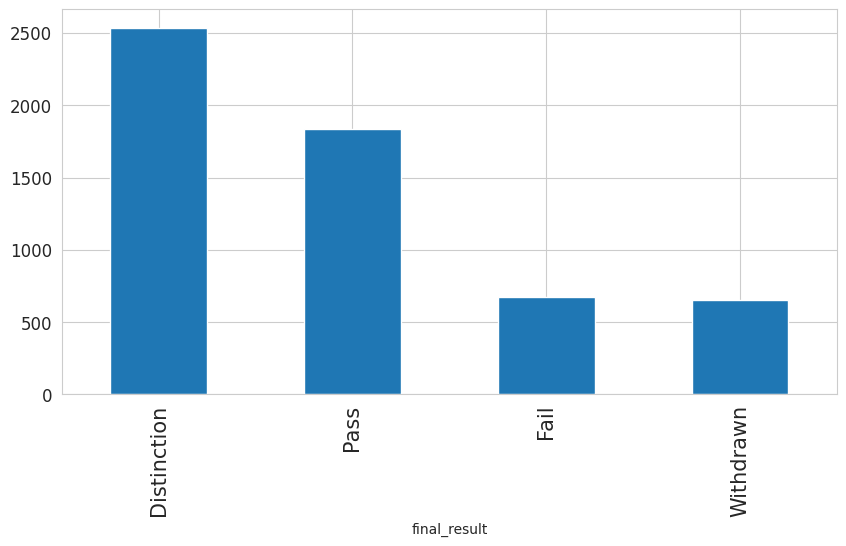

In [ ]:
plt.figure(figsize = (10, 5))
plt.xticks(rotation=90, fontsize=15)
plt.yticks(rotation=0, fontsize=12)
sns.set_style("whitegrid")
student_info.groupby(['final_result'])['After_Clicks'].mean().sort_values(ascending = False).plot(kind='bar')

<Axes: xlabel='final_result'>

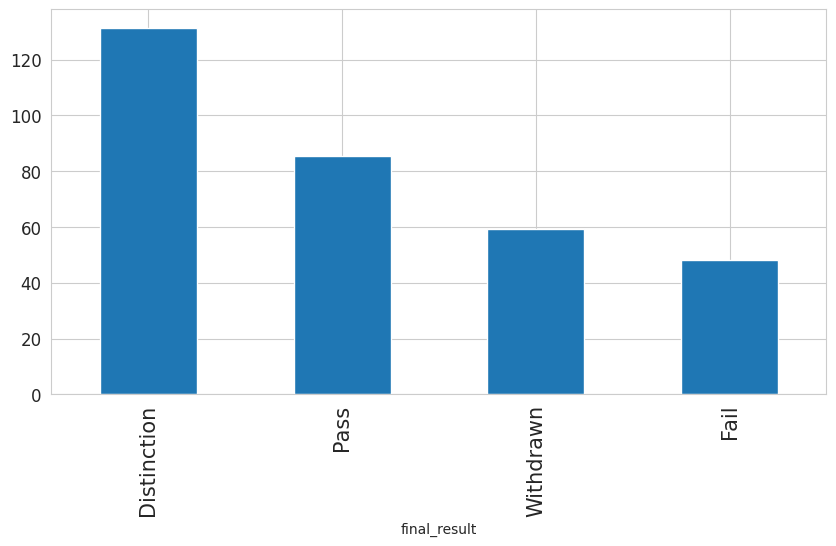

In [ ]:
## Even from the clicks data before the course even started, we can see that more the clicks more are the chances for student to pass.

plt.figure(figsize = (10, 5))
plt.xticks(rotation=90, fontsize=15)
plt.yticks(rotation=0, fontsize=12)
sns.set_style("whitegrid")
student_info.groupby(['final_result'])['Before_Clicks'].mean().sort_values(ascending = False).plot(kind='bar')

<Axes: xlabel='final_result'>

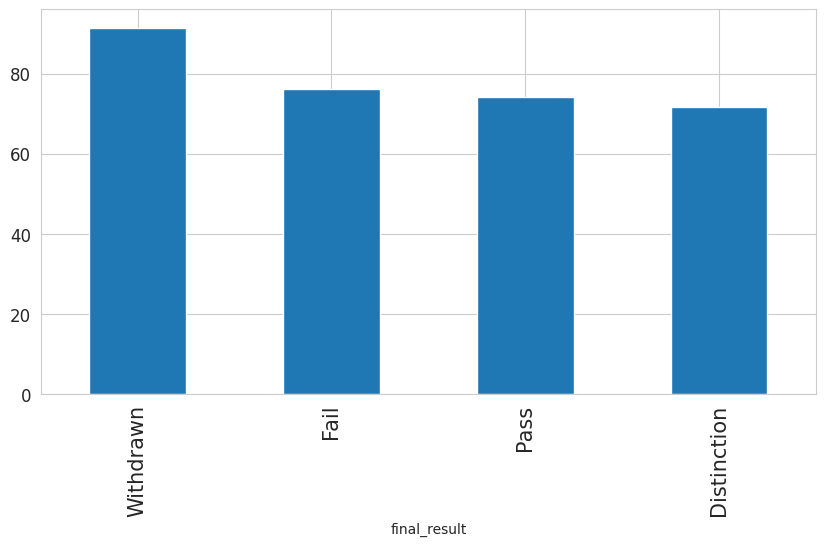

In [ ]:
## People with less credits have more chances to pass with distinction or pass because they have to study less
## People who withdrew has more average credits as compared to another.

plt.figure(figsize = (10, 5))
plt.xticks(rotation=90, fontsize=15)
plt.yticks(rotation=0, fontsize=12)
sns.set_style("whitegrid")
student_info.groupby(['final_result'])['studied_credits'].mean().sort_values(ascending = False).plot(kind='bar')

<Axes: xlabel='age_band'>

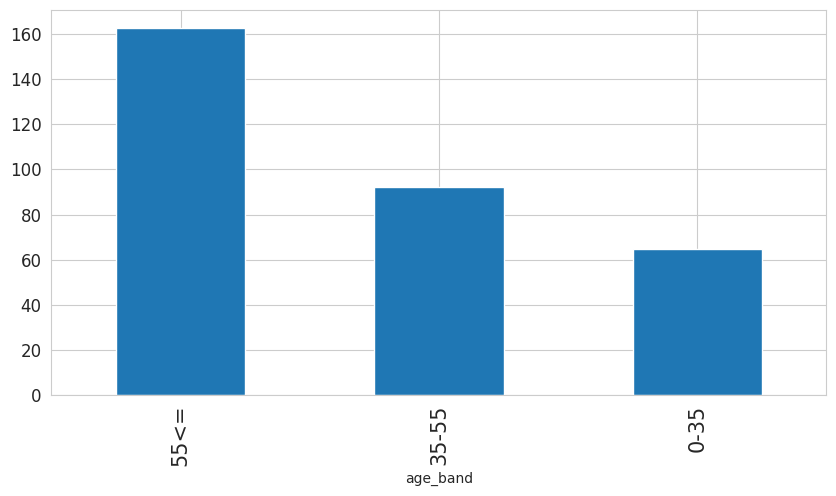

In [ ]:
plt.figure(figsize = (10, 5))
plt.xticks(rotation=90, fontsize=15)
plt.yticks(rotation=0, fontsize=12)
sns.set_style("whitegrid")
student_info.groupby(['age_band'])['Before_Clicks'].mean().sort_values(ascending = False).plot(kind='bar')

<Axes: xlabel='imd_band'>

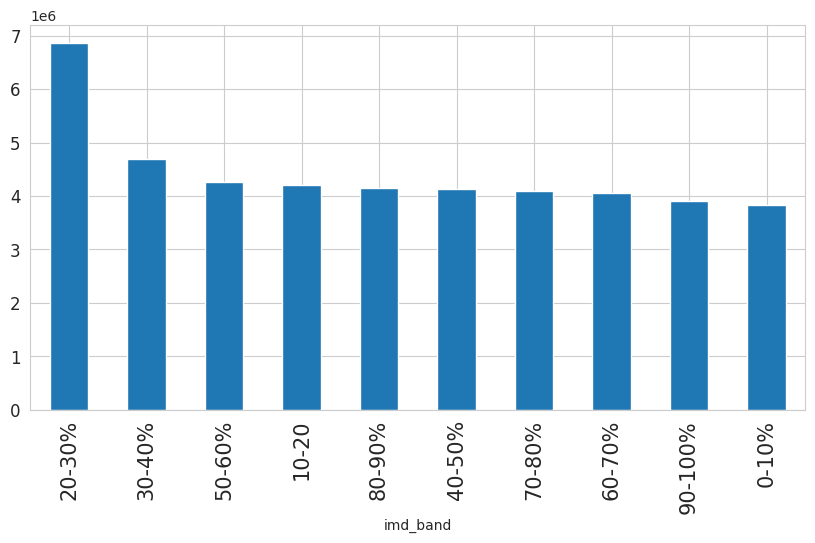

In [ ]:

plt.figure(figsize = (10, 5))
plt.xticks(rotation=90, fontsize=15)
plt.yticks(rotation=0, fontsize=12)
sns.set_style("whitegrid")
student_info.groupby(['imd_band'])['sum_click'].sum().sort_values(ascending = False).plot(kind='bar')

<Axes: xlabel='gender'>

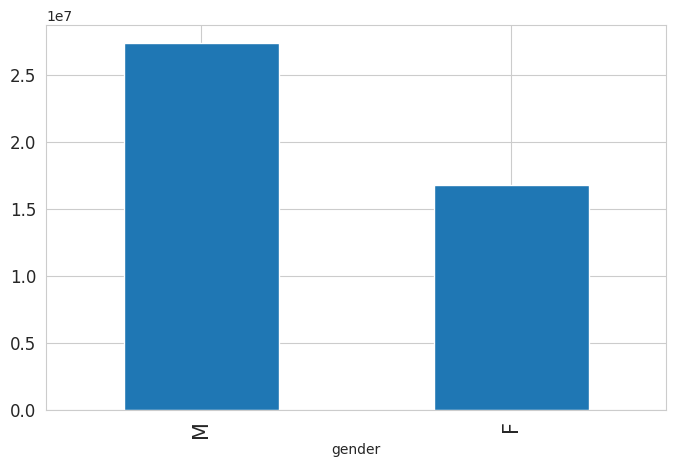

In [ ]:
plt.figure(figsize = (8, 5))
plt.xticks(rotation=90, fontsize=15)
plt.yticks(rotation=0, fontsize=12)
sns.set_style("whitegrid")
student_info.groupby(['gender'])['sum_click'].sum().sort_values(ascending = False).plot(kind='bar')

age_band  final_result
0-35      Pass            8469
          Withdrawn       7381
          Fail            5231
35-55     Pass            3800
          Withdrawn       2721
0-35      Distinction     1863
35-55     Fail            1792
          Distinction     1120
55<=      Pass              92
          Withdrawn         54
          Distinction       41
          Fail              29
Name: id_student, dtype: int64
final_result       Distinction       Fail       Pass  Withdrawn
age_band age_band                                              
0-35     0-35         8.119770  22.798989  36.911611  32.169630
35-55    35-55       11.873211  18.997138  40.284109  28.845542
55<=     55<=        18.981481  13.425926  42.592593  25.000000


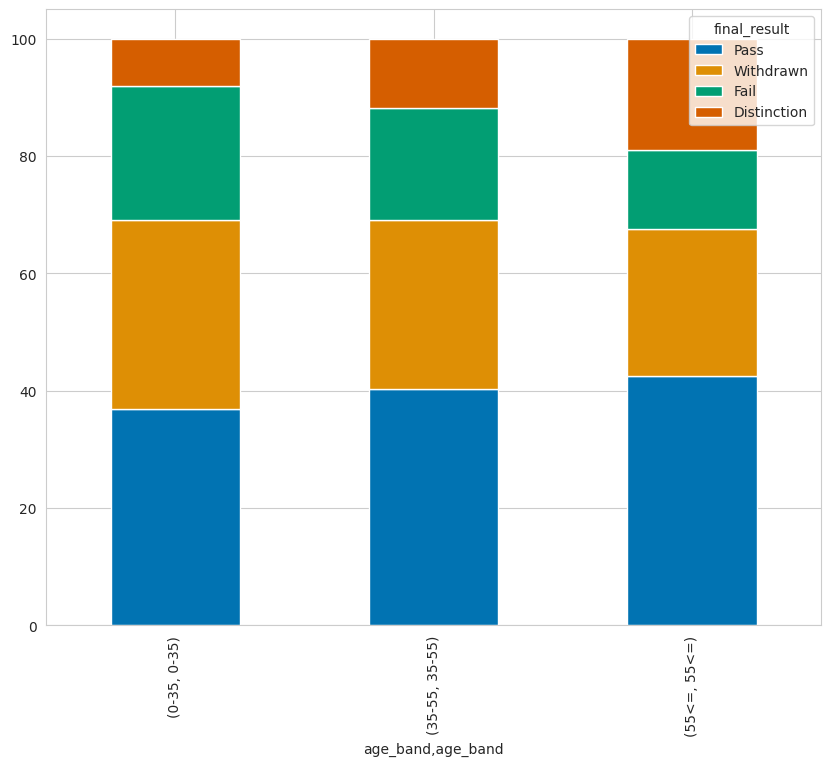

In [ ]:
## Following plot shows us the number of students in each result category. Most of the data is in age band 0-55.
## There are very few data points for age >= 55.
## We can see that Failure and Withdrawn rate is greater in age_band 0-35

print(student_info.groupby(['age_band', 'final_result'])['id_student'].count().sort_values(ascending = False))
stacked_plot(student_info, 'age_band', 'final_result', 'id_student', plot_size=(10, 8))

In [ ]:
# We can see from the plot that Failure Rate and Withdrawal Rate is high in people who have NO FORMAL EDUCATION and who have LOWER THAN A LEVEL EDUCATION
# Failure Rate is lowest in people who has Post Graduation.


#stacked_plot(student_info, 'highest_education', 'final_result', 'id_student', plot_size=(10, 8))

In [ ]:
student_info['highest_education'].unique()

array(['HE Qualification', 'A Level or Equivalent', 'Lower Than A Level',
       'Post Graduate Qualification', 'No Formal quals'], dtype=object)

In [ ]:
## Manioulating the feature higher_education

student_info['highest_education'] = [0 if education in ['A Level or Equivalent', 'Lower Than A Level', 'No Formal quals']
                                    else 1 for education in student_info['highest_education']]

In [ ]:
## We can see from the plot that students with lower education has higher failure rate than the ones who had higher education

#stacked_plot(student_info, 'highest_education', 'final_result', 'id_student', plot_size=(10, 8))

In [ ]:
## We can see that Failure Rate and Withdrawal rate is similar in all the regions.

#stacked_plot(student_info, 'region', 'final_result', 'id_student', plot_size=(15, 8))

In [ ]:
#stacked_plot(student_info, 'imd_band', 'final_result', 'id_student', plot_size=(15, 8))

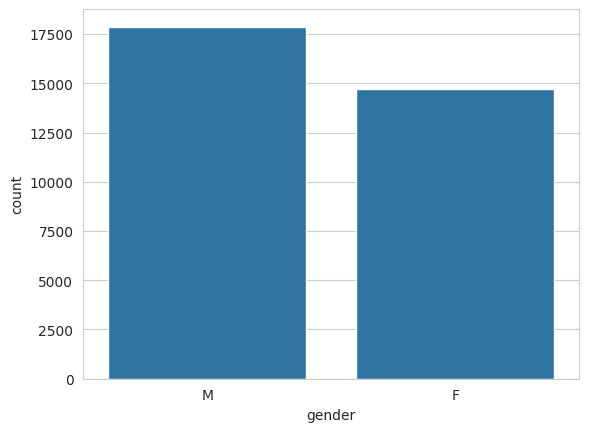

In [ ]:
# We can see that Males are more in number as compared to females
sns.countplot(x ='gender', data = student_info)

plt.show()

In [ ]:
## We can see that there is no difference between the Withdrawal Rates and Failure Rates for both the gender.

#stacked_plot(student_info, 'gender', 'final_result', 'id_student', plot_size=(10, 8))

In [ ]:
# Following plot shows us the results by disability.  Withdrawn Rate is more in People who are disable.


#stacked_plot(student_info, 'disability', 'final_result', 'id_student', plot_size=(15, 8))

Student Info & Student Registration

In [ ]:
student_registration_merge_courses = student_registration_merge_courses.drop('date_unregistration', axis = 1)

In [ ]:
student_info = student_info.merge(student_registration_merge_courses,
                                 on = ['code_module', 'code_presentation', 'id_student'],
                                 how = 'left')

In [ ]:
## Following Plot shows us the Result by Session. Failure Rate is more in people who took the course in February.
## Also withdrawn rate is slightly more in course starting in February.

#stacked_plot(student_info, 'Starting_Month', 'final_result', 'id_student', plot_size=(15, 8))

<Axes: xlabel='Starting_Month', ylabel='count'>

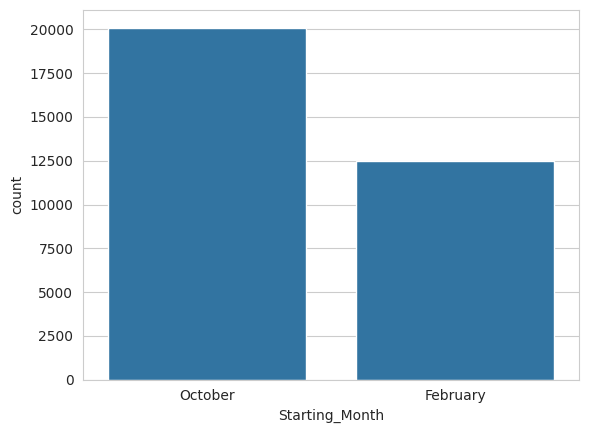

In [ ]:
## There are less people who registered in February as compared to October. But still the failure and withdrawn rate
## is more for february. May be the students don't like content or the course in February.
sns.countplot(x ='Starting_Month', data = student_info)

# Show the plot
#plt.show()

In [ ]:
## We can clearly see from the plot that we have the least failure and withdrawn rate in the students who did not
## took the course before or number of previous attempts are zero.

#stacked_plot(student_info, 'num_of_prev_attempts', 'final_result', 'id_student', plot_size=(15, 8))

In [ ]:
student_info['num_of_prev_attempts'] = [0 if attempts == 0 else 1 for attempts in student_info['num_of_prev_attempts']]

<Axes: xlabel='num_of_prev_attempts', ylabel='count'>

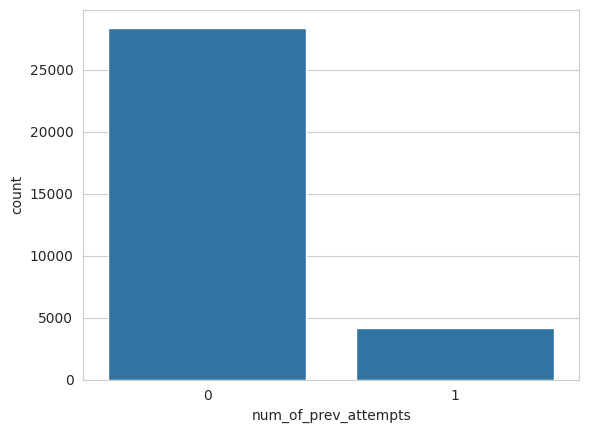

In [ ]:
## Still there is imbalance in the feature but it's better than the initial.
sns.countplot(x ='num_of_prev_attempts', data = student_info)

#plt.show()

In [ ]:
# We can clearly see that people with previous attempts have more failure and withdrawn rate.

#stacked_plot(student_info, 'num_of_prev_attempts', 'final_result', 'id_student', plot_size=(15, 8))

In [ ]:
## We can see that

#stacked_plot(student_info, 'code_module', 'final_result', 'id_student', plot_size=(15, 8))

In [ ]:
student_info['Code_Category'] = ['Social_Science' if student_info['code_module'].iloc[i] in ['AAA', 'BBB', 'GGG']
                                 else 'STEM' for i in range(len(student_info))]

In [ ]:
## From the following plot we can see that Failure Rate is higher in Social Science and Withdrawn rate is higher in STEM Courses.

#stacked_plot(student_info, 'Code_Category', 'final_result', 'id_student', plot_size=(15, 8))

# Data Preparation

In [ ]:
#student_info.head()


#finding which columns are in both student_info and student_assement
common_cols = set(student_info.columns).intersection(student_assessment_merge_assessment.columns)
print(common_cols)

#don't want to drop student id because this is how we will merge
common_cols.remove('id_student')

#dropping common columns
assessments_clean = student_assessment_merge_assessment.drop(columns=common_cols)

#merging student info with assessments
student_info = pd.merge(student_info, assessments_clean, on="id_student", how="left")

student_info.head()

{'code_presentation', 'code_module', 'Code_Category', 'id_student'}


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,sum_click,After_Clicks,Before_Clicks,date_registration,module_presentation_length,Year,Starting_Month,Code_Category,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight,Late_submission,Result,Weigthage
0,AAA,2013J,11391,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,2013,October,Social_Science,1752.0,18.0,0.0,78.0,TMA,19.0,10.0,1,Pass,Low_Weightage
1,AAA,2013J,11391,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,2013,October,Social_Science,1753.0,53.0,0.0,85.0,TMA,54.0,20.0,1,Pass,Medium_Weightage
2,AAA,2013J,11391,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,2013,October,Social_Science,1754.0,115.0,0.0,80.0,TMA,117.0,20.0,1,Pass,Medium_Weightage
3,AAA,2013J,11391,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,2013,October,Social_Science,1755.0,164.0,0.0,85.0,TMA,166.0,20.0,1,Pass,Medium_Weightage
4,AAA,2013J,11391,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,2013,October,Social_Science,1756.0,212.0,0.0,82.0,TMA,215.0,30.0,1,Pass,Medium_Weightage


In [ ]:
# In this step, I will remove code_presentation, id_student and Year as those won't have impact on the result

student_info = student_info.drop(['code_presentation', 'id_student', 'Year'], axis = 1)

In [ ]:
student_info['date_registration'] = student_info['date_registration'].astype(float)

In [ ]:
student_info['date_registration'].describe()

,date_registration
count,212958.000000
mean,67.928117
std,48.407263
min,0.000000
25%,29.000000
50%,54.000000
75%,96.000000
max,322.000000


In [ ]:
# There are two types of categorical variables in the data.
# 1. NOMINAL :- Here there is no order in the categories
# 2. ORDINAL :- When there is order in the category

#nominal_columns = ['gender', 'region', 'disability', 'Starting_Month', 'code_module', 'Code_Category']
#ordinal_columns = ['highest_education', 'imd_band', 'age_band']

# Function to Encode the Categorical Data Columns
# Parameters 1. df :- Dataframe 2. Column_name :- Feature to encode

#def categorical_encoding(df, column_name_list=[]):

 #   for column_name in column_name_list:
  #      print(df[column_name].unique())
   #     categorical_columns = pd.get_dummies(df[column_name], prefix = column_name,
    #                                         prefix_sep = '_', drop_first = False)
     #   df = pd.concat([df, categorical_columns], axis = 1)
      #  df = df.drop(column_name, axis = 1)
    #return df


# Function to Label Encode the data
# Parameters :- 1. data :- Dataframe 2. columns_list :- List of columns to label encode

#def labelEncoder(data, columns_list):
 #   for col in columns_list:
  #      encoder = LabelEncoder()
   #     data[col]  = encoder.fit_transform(data[col])
    #return data

#data = labelEncoder(student_info, ordinal_columns)
#data = categorical_encoding(student_info, nominal_columns)



# Start of Our Code

Importting, Cleansing, Merging, Data Preparation

In [ ]:
# Putting all the merging and dataset code here so we do not have to run everything whenever we reopen the document
student_info.isnull().sum()

student_info = student_info.dropna()

student_info.head()

,code_module,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,sum_click,After_Clicks,Before_Clicks,date_registration,module_presentation_length,Starting_Month,Code_Category,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight,Late_submission,Result,Weigthage
0,AAA,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,October,Social_Science,1752.0,18.0,0.0,78.0,TMA,19.0,10.0,1,Pass,Low_Weightage
1,AAA,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,October,Social_Science,1753.0,53.0,0.0,85.0,TMA,54.0,20.0,1,Pass,Medium_Weightage
2,AAA,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,October,Social_Science,1754.0,115.0,0.0,80.0,TMA,117.0,20.0,1,Pass,Medium_Weightage
3,AAA,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,October,Social_Science,1755.0,164.0,0.0,85.0,TMA,166.0,20.0,1,Pass,Medium_Weightage
4,AAA,M,East Anglian Region,1,90-100%,55<=,0,240,N,Pass,934.0,836.0,98.0,159.0,268,October,Social_Science,1756.0,212.0,0.0,82.0,TMA,215.0,30.0,1,Pass,Medium_Weightage


## Splitting Data

In [ ]:
student_info = student_info.drop(['id_assessment', 'After_Clicks', 'Before_Clicks', 'date'], axis = 1)

test = student_info
test['Result']  = [0 if result in ['Pass', 'Distinction'] else 1 for result in test['final_result']]
test

feature = test.drop(['final_result', 'Result'], axis = 1)
target  = test['Result']

target.value_counts()

,count
Result,
0,148328
1,58764


In [ ]:
#encode before splitting

feature = pd.get_dummies(feature, drop_first=True)

In [ ]:

#FIRST SPLITTING INTO TRAIN AND TEMP

X_train, X_temp, Y_train, Y_temp = train_test_split(
    feature, target,
    test_size=0.3,
    random_state=123,
    stratify=target
)

# SPLITTING TEMP INTO TEST AND VALIDATION
X_test, X_val, Y_test, Y_val = train_test_split(
    X_temp, Y_temp,
    test_size=1/3,
    random_state=123,
    stratify=Y_temp
)

#COMBINING X AND Y TO DOWNLOAD
train = pd.concat([X_train, Y_train], axis=1)
test = pd.concat([X_test, Y_test], axis=1)
val = pd.concat([X_val, Y_val], axis=1)

#SAVE AS CSV
train.to_csv('train.csv', index=False)
test.to_csv('test.csv', index=False)
val.to_csv('val.csv', index=False)

In [ ]:
train


,highest_education,num_of_prev_attempts,studied_credits,sum_click,date_registration,module_presentation_length,date_submitted,is_banked,score,weight,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,gender_M,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55<=,disability_Y,Starting_Month_October,Code_Category_Social_Science,assessment_type_Exam,assessment_type_TMA,Late_submission_1,Weigthage_Low_Weightage,Weigthage_Medium_Weightage,Result
205588,0,0,60,331.0,50.0,241,152.0,0.0,100.0,0.0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,True,False,0
406,0,0,60,1418.0,73.0,268,63.0,0.0,70.0,20.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,True,False,False,True,1
167344,0,0,90,4070.0,26.0,241,170.0,0.0,99.0,25.0,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,True,0
111023,1,0,90,1046.0,28.0,241,219.0,0.0,96.0,8.0,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,0
160408,0,0,120,3759.0,91.0,268,234.0,0.0,86.0,0.0,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47465,0,0,60,73.0,11.0,262,40.0,0.0,64.0,10.0,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,True,True,True,False,1
105131,0,0,60,1086.0,60.0,261,71.0,0.0,89.0,17.5,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,True,False,True,0
164051,0,0,120,7618.0,38.0,268,95.0,0.0,90.0,25.0,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,True,False,True,0
37997,0,0,60,433.0,31.0,234,119.0,0.0,80.0,1.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,0


In [ ]:
# Check Multicollinearity (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

# Assume X_train_encoded is already one-hot encoded and float
# Add constant for intercept (needed for statsmodels)
X_train_const = sm.add_constant(X_train)

# Create DataFrame to hold VIF values
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_const.columns

# Calculate VIF for each feature
vif_data['VIF'] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

print(vif_data.sort_values('VIF', ascending=False))

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

Here we have high VIF. We want to drpop any below 10, but code_module and region should be okayish to keep.

In [ ]:
#REMOVE HIGH VIF AND TEST AGAIN

#X_train_encoded = X_train_encoded.drop("sum_click", axis = 1)

X_train_const = sm.add_constant(X_train)

# Create DataFrame to hold VIF values
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_const.columns

# Calculate VIF for each feature
vif_data['VIF'] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

print(vif_data.sort_values('VIF', ascending=False))


In [ ]:
# Check if sum_click is derived from others
test['check'] = test['Before_Clicks'] + test['After_Clicks']
test['check'].equals(test['sum_click'])  # if True, drop sum_click or components


## XGBoost

In [ ]:
# One-hot encode categorical variables
#X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Force all values to float (prevents "object" dtype)
#X_test_encoded = X_test_encoded.astype(float)

clean = lambda c: c.replace('[', '(').replace(']', ')').replace('<', 'LT_')

X_train.columns = [clean(c) for c in X_train.columns]
X_test.columns  = [clean(c) for c in X_test.columns]

Accuracy: 0.8519484282196147
ROC AUC: 0.9041772882865587

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     29666
           1       0.82      0.61      0.70     11752

    accuracy                           0.85     41418
   macro avg       0.84      0.78      0.80     41418
weighted avg       0.85      0.85      0.84     41418



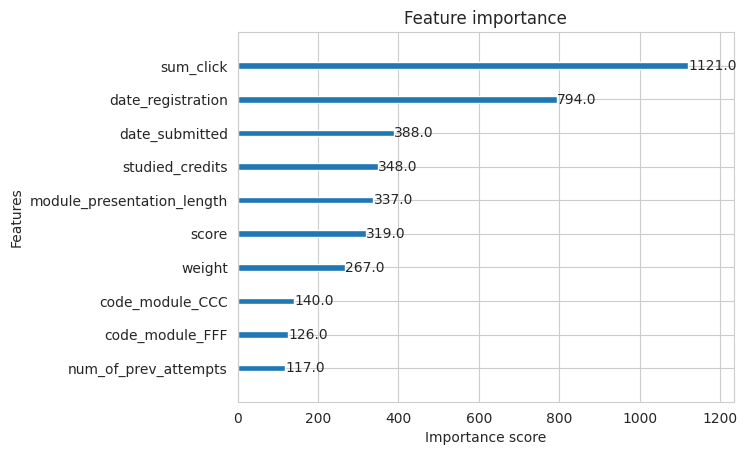

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

dtrain = xgb.DMatrix(X_train, label=Y_train)
dtest = xgb.DMatrix(X_test, label=Y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 5,
    'eta' : 0.1,
    'subsample' : 0.8,
    'colsample_bytree': 0.8,
    'random_state': 123
}

xgb_model = xgb.train(params, dtrain, num_boost_round=200, evals=[(dtest, 'test')], early_stopping_rounds=20, verbose_eval=False)

y_pred_prob = xgb_model.predict(dtest)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(Y_test, y_pred))
print("ROC AUC:", roc_auc_score(Y_test, y_pred_prob))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))


#feature importance
xgb.plot_importance(xgb_model, max_num_features=10)
plt.show()

## Random Forest

Random Forest Accuracy: 0.7572

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.99      0.85     29666
           1       0.90      0.16      0.27     11752

    accuracy                           0.76     41418
   macro avg       0.83      0.58      0.56     41418
weighted avg       0.79      0.76      0.69     41418



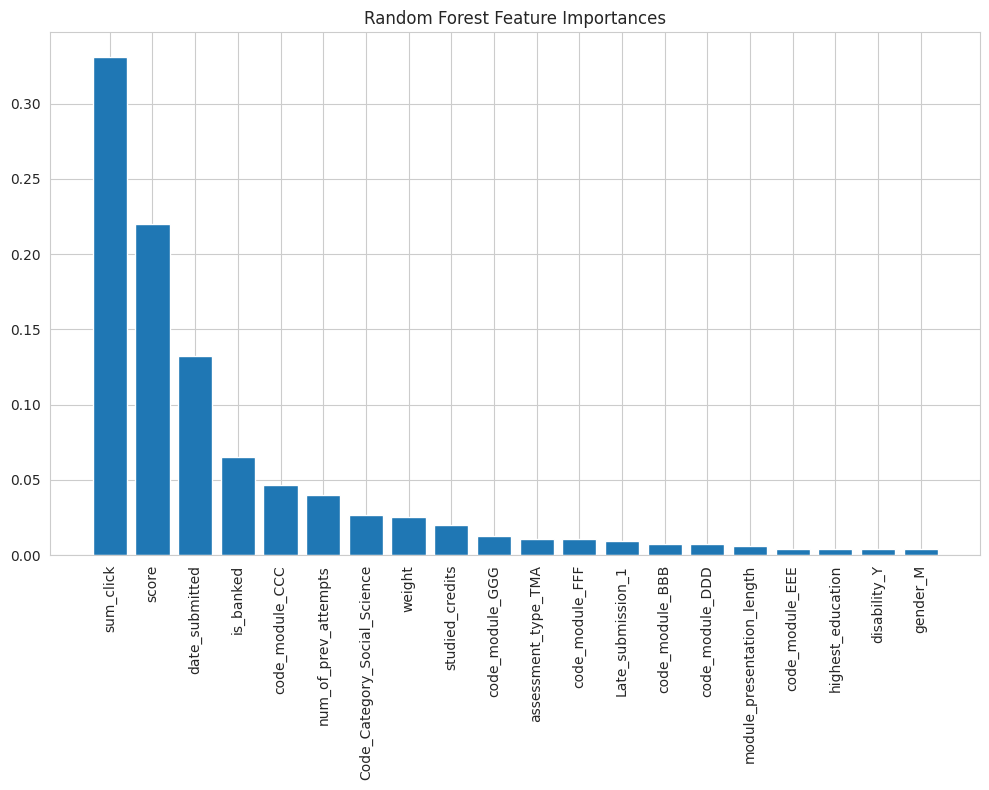

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,     # number of trees
    max_depth=4,      # can tune
    random_state=123,
)

rf.fit(X_train, Y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluate
accuracy = accuracy_score(Y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(Y_test, y_pred))

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(10, 8))
plt.title("Random Forest Feature Importances")
plt.bar(range(20), importances[indices[:20]], align='center')
plt.xticks(range(20), feature_names[indices[:20]], rotation=90)
plt.tight_layout()
plt.show()


## Decision Tree

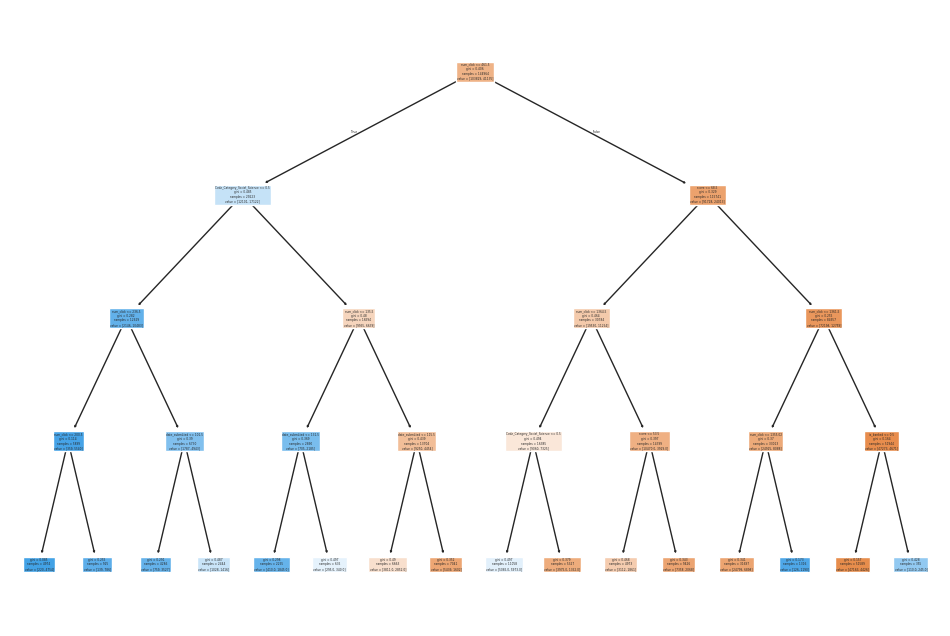

Decision Tree Accuracy: 0.7935

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.86     29666
           1       0.70      0.47      0.57     11752

    accuracy                           0.79     41418
   macro avg       0.76      0.70      0.72     41418
weighted avg       0.78      0.79      0.78     41418



In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Create and train the model
dt = DecisionTreeClassifier(
    criterion='gini',       # or 'entropy'
    max_depth=4,         # can tune later
    random_state=123
)

dt.fit(X_train, Y_train)

# Predictions
y_pred = dt.predict(X_test)

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=X_test.columns, filled=True)
plt.show()

# Evaluate
accuracy = accuracy_score(Y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(Y_test, y_pred))


# Old Test/Train & RFC

In [ ]:
### Here we will split our data into training and testing. As we have less data, I will keep 80% of the data for
### training and only 20% for testing. I would like to have more data where I can create three separate datasets
### for training, validation and testing. As our objective here is to find features which impact the decision whether
### student will fail or not, I will use most for training only.

X_train, X_test, Y_train, Y_test = train_test_split(feature, target,
                                                    test_size = 0.2,
                                                    random_state = 123,
                                                    stratify=data.final_result)

In [ ]:
# In this step I will create a feature and target set for the dropout vs non-dropout case

feature_dropout = data.drop(['final_result', 'dropout', 'Result'], axis = 1)
target_dropout  = data['dropout']

In [ ]:
target_dropout.value_counts()

In [ ]:
## Splitting Data into training and test sets

X_train_dropout, X_test_dropout, Y_train_dropout, Y_test_dropout = train_test_split(feature_dropout, target_dropout,
                                                                                    test_size = 0.2,
                                                                                    random_state = 123,
                                                                                    stratify=target_dropout)

# Building & Evaluating Model

In [ ]:
## Initializing the Random Forest Model

random_forest_model = RandomForestClassifier(n_estimators=100,
                                             random_state=123,
                                             max_depth=25,
                                             min_samples_split = 100,
                                             n_jobs=4)

In [ ]:
## Fitting the model using Training Data

random_forest_model.fit(X_train, Y_train)

In [ ]:
## Predicting on Test Data using fitted model

predictions_random = random_forest_model.predict(X_test)

In [ ]:
print(confusion_matrix(Y_test, predictions_random))

In [ ]:
print("Accuracy of the model is ", accuracy_score(Y_test, predictions_random))

In [ ]:
print(classification_report(Y_test, predictions_random, digits=2))

In [ ]:
predictions_rf = random_forest_model.predict_proba(X_test)
preds = predictions_rf[:,1]
y_test = np.array(Y_test)
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Grid Search

In [ ]:
random_forest_model_best_fit = RandomForestClassifier(n_estimators=100,
                                                      random_state=123,
                                                      max_depth=30,
                                                      min_samples_split = 50,
                                                      n_jobs=4)

In [ ]:
random_forest_model_best_fit.fit(X_train, Y_train)

In [ ]:
predict_best_fit = random_forest_model_best_fit.predict(X_test)

In [ ]:
print(classification_report(predict_best_fit, Y_test))

In [ ]:
## We can see that region has close to None impact on the output of the model. So we will remove this feature.

importance = pd.concat([pd.DataFrame(X_train.columns),
                          pd.DataFrame(np.transpose(random_forest_model.feature_importances_))], axis = 1)
importance.columns = ['Features', 'Coeff']
importance = importance.sort_values('Coeff', ascending=False)
importance

In [ ]:
#Building amodel to predict whether student will dropout or not
# I am using class weight in this case because we have less samples for class = 1 which is dropout

random_forest_model_drop = RandomForestClassifier(n_estimators=100,
                                                  random_state=123,
                                                  max_depth=25,
                                                  min_samples_split = 100,
                                                  class_weight = {0: 1, 1: 2},
                                                  n_jobs=4)

In [ ]:
random_forest_model_drop.fit(X_train_dropout, Y_train_dropout)

In [ ]:
predict_dropout = random_forest_model_drop.predict(X_test_dropout)

In [ ]:
print(classification_report(predict_dropout, Y_test_dropout))

In [ ]:
predictions_rf = random_forest_model_drop.predict_proba(X_test_dropout)
preds = predictions_rf[:,1]
y_test = np.array(Y_test_dropout)
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
importance = pd.concat([pd.DataFrame(X_train_dropout.columns),
                          pd.DataFrame(np.transpose(random_forest_model_drop.feature_importances_))], axis = 1)
importance.columns = ['Features', 'Coeff']
importance = importance.sort_values('Coeff', ascending=False)
importance